<a href="https://colab.research.google.com/github/patinohoyosgisell/Challenge_Telecom_X/blob/main/Challenge_Telecom_XV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracción

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
!pip install requests


In [231]:
import requests
import json

In [232]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
datos = requests.get(url).json()

In [233]:
#Convirtiendo a DataFrame
df = pd.DataFrame(datos)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformación

In [234]:
#normalizando los datos
df = pd.json_normalize(datos)
df.tail()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [235]:
# Ver nombres de columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [236]:
#convirtiendo tipo variable object a float64
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [238]:
#nombres de columnas
print(df.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


In [239]:
# reiniciar el df para garantizar que los nombres de las columnas guarden bien
df = pd.json_normalize(datos)

# Estandarizando todos los nombres en minúsculas
df.columns = df.columns.str.lower()

In [240]:
df.isnull().values.any()

np.False_

In [241]:
df.isnull().sum()

,0
customerid,0
churn,0
customer.gender,0
customer.seniorcitizen,0
customer.partner,0
customer.dependents,0
customer.tenure,0
phone.phoneservice,0
phone.multiplelines,0
internet.internetservice,0


In [242]:
df['churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [243]:
import numpy as np

df = df.replace(r'^\s*$', np.nan, regex=True)

In [244]:
cols_yes_no = df.columns[df.isin(['Yes','No']).any()]

df[cols_yes_no] = df[cols_yes_no].replace({'Yes':1,'No':0})

df[cols_yes_no] = df[cols_yes_no].fillna(2)

/tmp/ipykernel_139/700231018.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yes_no] = df[cols_yes_no].replace({'Yes':1,'No':0})


In [245]:
df.head()

,customerid,churn,customer.gender,customer.seniorcitizen,customer.partner,customer.dependents,customer.tenure,phone.phoneservice,phone.multiplelines,internet.internetservice,...,internet.onlinebackup,internet.deviceprotection,internet.techsupport,internet.streamingtv,internet.streamingmovies,account.contract,account.paperlessbilling,account.paymentmethod,account.charges.monthly,account.charges.total
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   int64  
 5   customer.dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   int64  
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

In [247]:
#convirtiendo tipo variable object a int64
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')
df['account.charges.total'] = pd.to_numeric(df['account.charges.total'], errors='coerce')


In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   int64  
 5   customer.dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   int64  
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

In [249]:
#valores duplicados
df.duplicated().sum()

np.int64(0)

In [250]:
# Traducción de nombres de columnas
traduccion_columnas = {
    "customerid": "id_cliente",
    "churn": "cancelacion",
    "customer.gender": "cliente.genero",
    "customer.seniorcitizen": "cliente.ciudadano_senior",
    "customer.partner": "cliente.pareja",
    "customer.dependents": "cliente.dependientes",
    "customer.tenure": "cliente.antiguedad",
    "phone.phoneservice": "telefono.servicio_telefonico",
    "phone.multiplelines": "telefono.lineas_multiples",
    "internet.internetservice": "internet.servicio_internet",
    "internet.onlinesecurity": "internet.seguridad_en_linea",
    "internet.onlinebackup": "internet.copia_seguridad",
    "internet.deviceprotection": "internet.proteccion_dispositivo",
    "internet.techsupport": "internet.soporte_tecnico",
    "internet.streamingtv": "internet.tv_streaming",
    "internet.streamingmovies": "internet.peliculas_streaming",
    "account.contract": "cuenta.contrato",
    "account.paperlessbilling": "cuenta.facturacion_sin_papel",
    "account.paymentmethod": "cuenta.metodo_pago",
    "account.charges.monthly": "cuenta.cargos_mensuales",
    "account.charges.total": "cuenta.cargos_totales"
}

df = df.rename(columns=traduccion_columnas)

# Traducción de valores
traduccion_valores = {
    "Yes": "Si",
    "No": "No",
    "Female": "Mujer",
    "Male": "Hombre",
    "No phone service": "Sin servicio telefonico",
    "No internet service": "Sin servicio de internet",
    "DSL": "DSL",
    "Fiber optic": "Fibra optica",
    "Month-to-month": "Mes a mes",
    "One year": "Un año",
    "Two year": "Dos años",
    "Electronic check": "Cheque electronico",
    "Mailed check": "Cheque por correo",
    "Credit card (automatic)": "Tarjeta de credito (automatica)",
    "Bank transfer (automatic)": "Transferencia bancaria (automatica)"
}

# Aplicar traducciones a todas las columnas de tipo "object"
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].replace(traduccion_valores)

print("Traducción aplicada:")
print(df.head(3))


Traducción aplicada:
   id_cliente  cancelacion cliente.genero  cliente.ciudadano_senior  \
0  0002-ORFBO          0.0          Mujer                         0   
1  0003-MKNFE          0.0         Hombre                         0   
2  0004-TLHLJ          1.0         Hombre                         0   

   cliente.pareja  cliente.dependientes  cliente.antiguedad  \
0               1                     1                   9   
1               0                     0                   9   
2               0                     0                   4   

   telefono.servicio_telefonico telefono.lineas_multiples  \
0                             1                         0   
1                             1                         1   
2                             1                         0   

  internet.servicio_internet  ... internet.copia_seguridad  \
0                        DSL  ...                        1   
1                        DSL  ...                        0   
2         

In [251]:
print(df.columns)

Index(['id_cliente', 'cancelacion', 'cliente.genero',
       'cliente.ciudadano_senior', 'cliente.pareja', 'cliente.dependientes',
       'cliente.antiguedad', 'telefono.servicio_telefonico',
       'telefono.lineas_multiples', 'internet.servicio_internet',
       'internet.seguridad_en_linea', 'internet.copia_seguridad',
       'internet.proteccion_dispositivo', 'internet.soporte_tecnico',
       'internet.tv_streaming', 'internet.peliculas_streaming',
       'cuenta.contrato', 'cuenta.facturacion_sin_papel', 'cuenta.metodo_pago',
       'cuenta.cargos_mensuales', 'cuenta.cargos_totales'],
      dtype='object')


In [252]:
df['cuentas_diarias'] = (df['cuenta.cargos_mensuales'] / 30).round(1)

Se crea la variable Cuentas_Diarias a partir de la facturación mensual para analizar el gasto promedio diario de los clientes.

In [253]:
df[['cuenta.cargos_mensuales', 'cuentas_diarias']].head()

,cuenta.cargos_mensuales,cuentas_diarias
0,65.6,2.2
1,59.9,2.0
2,73.9,2.5
3,98.0,3.3
4,83.9,2.8


# 📊 Carga y análisis

In [254]:
#Análisis descriptivo
df.describe()

,cancelacion,cliente.ciudadano_senior,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,cuenta.facturacion_sin_papel,cuenta.cargos_mensuales,cuenta.cargos_totales,cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.318839,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.158745
std,0.528079,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.002283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.600000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.200000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.300000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,3.000000
max,2.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,4.000000


In [255]:
df['cancelacion'].value_counts()

,count
cancelacion,
0.0,5174
1.0,1869
2.0,224


# 📄Informe final

In [256]:
import matplotlib.pyplot as plt

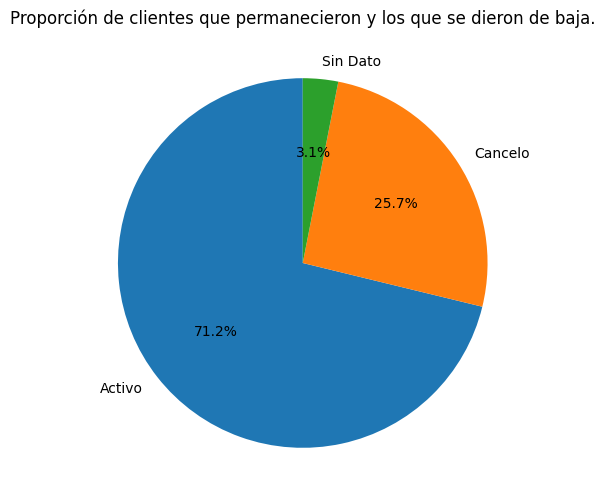

In [259]:
import matplotlib.pyplot as plt

cancelacion_part = df['cancelacion'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    cancelacion_part,
    labels=['Activo','Cancelo', 'Sin Dato'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporción de clientes que permanecieron y los que se dieron de baja.')
plt.show()